# 01 — Buildings

Everything the Area API knows about buildings is exposed via
`client.buildings.get_area(polygon)`. This notebook covers:

- the `AreaBuildings` return type
- the per-building `DotBimMesh` format
- the per-tile coordinate frame and how building heights are encoded
- a top-down footprint visualisation

In [1]:
from dotenv import load_dotenv
load_dotenv()

from infrared_sdk import InfraredClient
from cities import get

city = get("munich")
print(f"City: {city.name}  ({city.latitude}, {city.longitude})")

City: Munich  (48.1374, 11.5755)


## Fetch the area

`get_area` may transparently issue multiple sub-requests if the polygon
spans more than one server-side tile, then deduplicates and returns one
flat `dict[building_id -> DotBimMesh]`.

In [2]:
with InfraredClient() as client:
    area = client.buildings.get_area(city.polygon_small)

print(f"total_buildings : {area.total_buildings}")
print(f"buildings keys  : {list(area.buildings)[:5]} ...")

total_buildings : 340
buildings keys  : ['781ef62e-4253-4d45-b46b-3ef130ec4eac', '3cbf695d-7f8e-40a7-b128-0682f8474fd9', 'ebf05037-3a2e-4978-9630-83441abb72b1', 'fa627947-5af4-4087-a787-7833d368a4de', '74072b42-60af-4a08-ba53-4c9778cd2423'] ...


## Anatomy of a `DotBimMesh`

Each building is an extruded mesh: a flat `[x, y, z, x, y, z, ...]`
coordinate array plus a triangle-index array. The z values encode
building height directly (`max(z) - min(z)`).

In [3]:
import numpy as np

bid, mesh = next(iter(area.buildings.items()))
mesh_dict = mesh.model_dump(by_alias=True) if hasattr(mesh, "model_dump") else mesh

coords = np.array(mesh_dict["coordinates"], dtype=float).reshape(-1, 3)
indices = np.array(mesh_dict["indices"], dtype=int).reshape(-1, 3)
print(f"building     : {bid}")
print(f"vertices     : {len(coords)}")
print(f"triangles    : {len(indices)}")
print(f"height (m)   : {coords[:, 2].max() - coords[:, 2].min():.2f}")
print(f"footprint x range : [{coords[:, 0].min():.1f}, {coords[:, 0].max():.1f}] m")
print(f"footprint y range : [{coords[:, 1].min():.1f}, {coords[:, 1].max():.1f}] m")

building     : 781ef62e-4253-4d45-b46b-3ef130ec4eac
vertices     : 114
triangles    : 72
height (m)   : 14.50
footprint x range : [229.1, 384.8] m
footprint y range : [383.5, 418.5] m


## Distribution of heights

Buildings are returned with metric heights in the per-tile coordinate
frame. Plotting a histogram is a quick sanity check that data exists
and looks plausible.

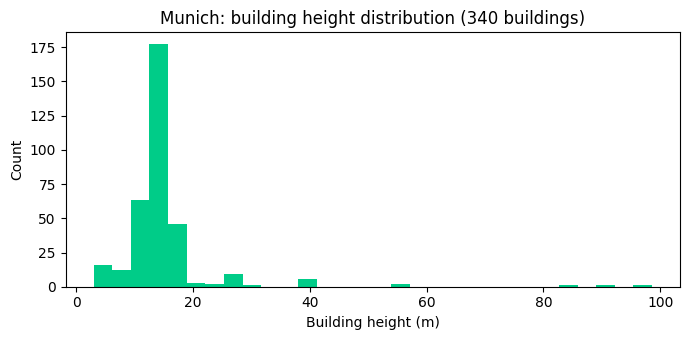

min     : 3.0 m
median  : 15.5 m
max     : 98.6 m


In [4]:
import matplotlib.pyplot as plt

heights = []
for m in area.buildings.values():
    md = m.model_dump(by_alias=True) if hasattr(m, "model_dump") else m
    z = np.array(md["coordinates"], dtype=float).reshape(-1, 3)[:, 2]
    heights.append(float(z.max() - z.min()))

plt.figure(figsize=(7, 3.5))
plt.hist(heights, bins=30, color="#0c8")
plt.xlabel("Building height (m)")
plt.ylabel("Count")
plt.title(f"{city.name}: building height distribution ({len(heights)} buildings)")
plt.tight_layout()
plt.show()

print(f"min     : {min(heights):.1f} m")
print(f"median  : {sorted(heights)[len(heights)//2]:.1f} m")
print(f"max     : {max(heights):.1f} m")

## Footprint plot

Project each building's bottom-face vertices into 2D and draw the convex
hull. This gives you a top-down "where are the buildings?" view in the
local meter frame.

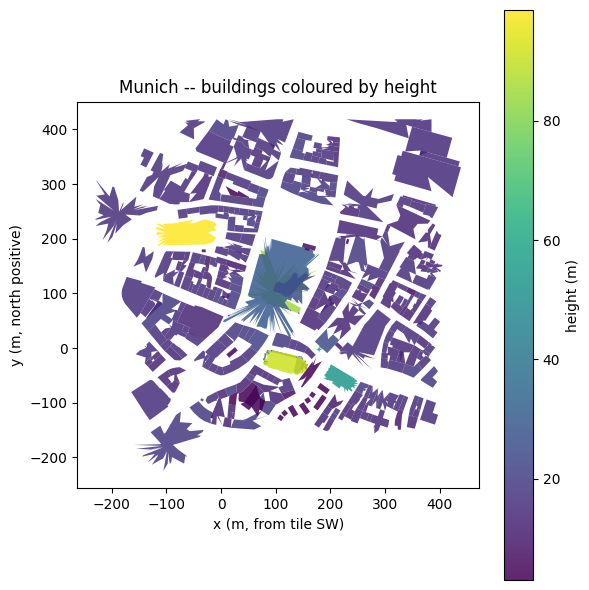

In [5]:
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

fig, ax = plt.subplots(figsize=(6, 6))
patches, hs = [], []
for m in area.buildings.values():
    md = m.model_dump(by_alias=True) if hasattr(m, "model_dump") else m
    pts = np.array(md["coordinates"], dtype=float).reshape(-1, 3)
    bottom = pts[np.isclose(pts[:, 2], pts[:, 2].min(), atol=0.05)][:, :2]
    if len(bottom) < 3:
        continue
    # Sort by polar angle for a clean polygon outline.
    cx, cy = bottom.mean(0)
    order = np.argsort(np.arctan2(bottom[:, 1] - cy, bottom[:, 0] - cx))
    patches.append(MplPolygon(bottom[order]))
    hs.append(pts[:, 2].max() - pts[:, 2].min())

pc = PatchCollection(patches, cmap="viridis", alpha=0.85)
pc.set_array(np.array(hs))
ax.add_collection(pc)
ax.set_aspect("equal")
ax.autoscale()
ax.set_xlabel("x (m, from tile SW)"); ax.set_ylabel("y (m, north positive)")
ax.set_title(f"{city.name} -- buildings coloured by height")
fig.colorbar(pc, ax=ax, label="height (m)")
plt.tight_layout()
plt.show()

## Notes

- **Coordinate frame.** Coordinates are in **meters relative to the
  tile's SW corner** (x = east, y = north, z = up). For a single-tile
  polygon the tile SW is the polygon's bbox SW.
- **Multi-tile polygons.** Buildings that straddle a tile boundary are
  returned in **all** tiles they touch, with their full (unclipped)
  geometry. The orchestrator handles this for you when you pass
  `area.buildings` to `run_area_and_wait`.
- **DotBim format.** Same schema as the [.bim](https://dotbim.net) format
  used in BIM workflows -- you can export to `.bim` files for use in
  Rhino, Blender, Three.js, etc.

Next: `02_vegetation_and_ground.ipynb` covers trees and surface materials.